### 우리지역 인구와 연령대별 인구 분포 알아보기
- 서울시 송파구 2016.12 - 2025.12 주민등록인구 세대 현황

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("./pop_datas/201612_202512_주민등록인구및세대현황_연간.csv", encoding="cp949")
# print(df.head())

In [77]:
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


In [78]:
# 송파구 전체 행과 행정동 분리
songpa_total = df.iloc[[0]].copy()
df_dong = df.iloc[1:].copy()

# 행정구역명에서 동 이름만 추출
# 예: "서울특별시 송파구 풍납1동(1171051000)" -> "풍납1동"
df_dong["동"] = (
    df_dong["행정구역"]
    .str.replace("서울특별시 송파구 ", "", regex=False)
    .str.replace(r"\(\d+\)", "", regex=True)
    .str.strip()
)

# 쉼표가 포함된 숫자 컬럼 변환
for year in range(2016, 2026):
    for col_type in ["총인구수", "세대수", "남자 인구수", "여자 인구수"]:
        col = f"{year}년_{col_type}"

        df_dong[col] = (
            df_dong[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

    df_dong[f"{year}년_세대당 인구"] = pd.to_numeric(
        df_dong[f"{year}년_세대당 인구"],
        errors="coerce"
    )

    df_dong[f"{year}년_남여 비율"] = pd.to_numeric(
        df_dong[f"{year}년_남여 비율"],
        errors="coerce"
    )

print(df_dong[["동", "2016년_총인구수", "2025년_총인구수"]].head())

      동  2016년_총인구수  2025년_총인구수
1  풍납1동       17031       10753
2  풍납2동       25646       22922
3  거여1동       14652       11725
4  거여2동       19502       23058
5  마천1동       22674       15169


### 행정동별 인구 비중

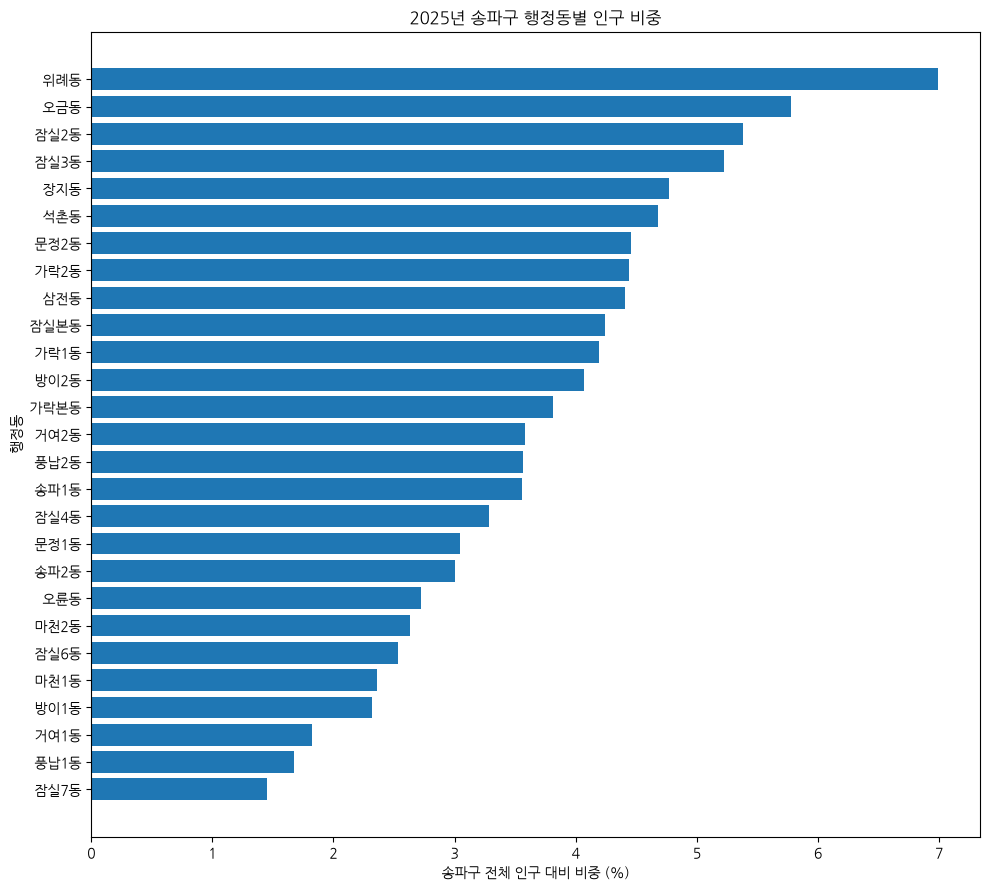

In [79]:
df_dong["2025년_인구비중"] = (
    df_dong["2025년_총인구수"]
    / df_dong["2025년_총인구수"].sum()
    * 100
)

share = (
    df_dong[["동", "2025년_인구비중"]]
    .sort_values("2025년_인구비중", ascending=True)
)

plt.figure(figsize=(10, 9))

plt.barh(
    share["동"],
    share["2025년_인구비중"]
)

plt.xlabel("송파구 전체 인구 대비 비중 (%)")
plt.ylabel("행정동")
plt.title("2025년 송파구 행정동별 인구 비중")

plt.tight_layout()
plt.show()

### 행정동별 2016 - 2025 인구 증감률

In [80]:
df_dong["인구증감률"] = (
    (
        df_dong["2025년_총인구수"]
        - df_dong["2016년_총인구수"]
    )
    / df_dong["2016년_총인구수"]
    * 100
)

population_change = (
    df_dong[["동", "인구증감률"]]
    .sort_values("인구증감률")
)

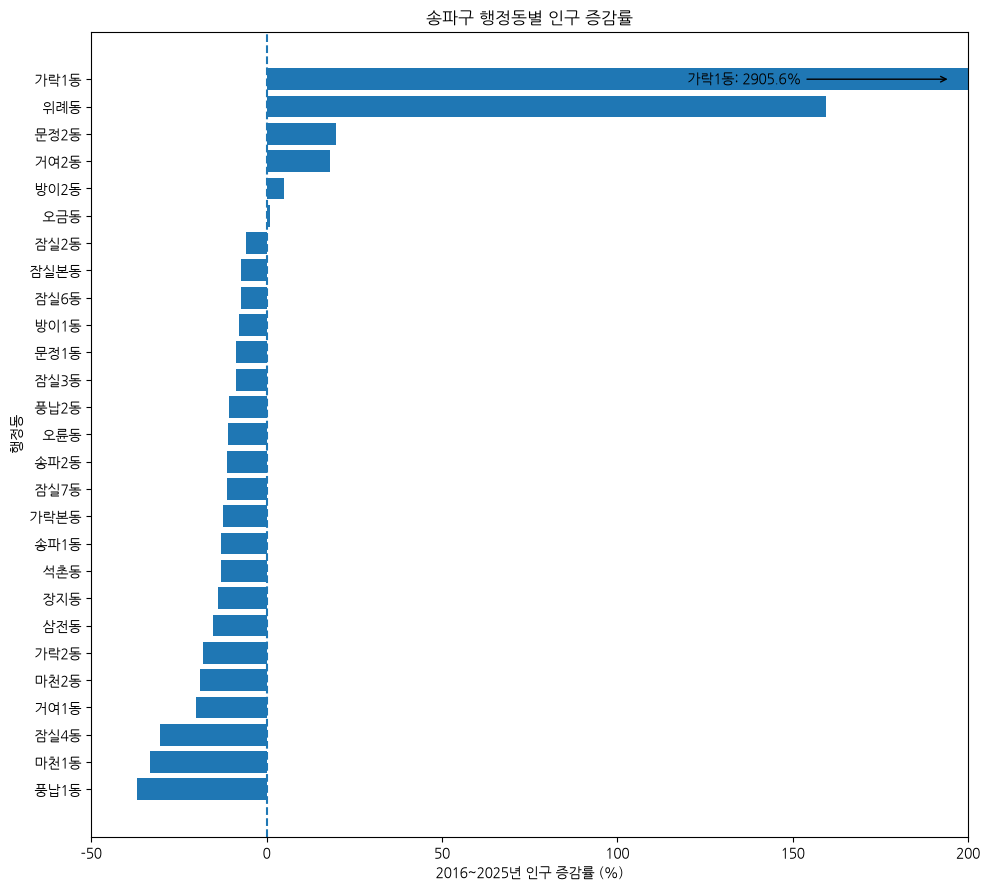

In [81]:
population_change = (
    df_dong[["동", "인구증감률"]]
    .sort_values("인구증감률", ascending=True)
)

plt.figure(figsize=(10, 9))

plt.barh(
    population_change["동"],
    population_change["인구증감률"]
)

plt.axvline(0, linestyle="--")

# 일반적인 데이터 범위에 초점을 맞춤
plt.xlim(-50, 200)

# 가락1동 실제 값 표시
garak_value = population_change.loc[
    population_change["동"] == "가락1동",
    "인구증감률"
].iloc[0]

garak_y = population_change.reset_index(drop=True).index[
    population_change.reset_index(drop=True)["동"] == "가락1동"
][0]

plt.annotate(
    f"가락1동: {garak_value:.1f}%",
    xy=(195, garak_y),
    xytext=(120, garak_y),
    arrowprops={"arrowstyle": "->"},
    va="center"
)

plt.xlabel("2016~2025년 인구 증감률 (%)")
plt.ylabel("행정동")
plt.title("송파구 행정동별 인구 증감률")

plt.tight_layout()
plt.show()

In [111]:
incline_top5 = (
    df_dong.nlargest(5, "인구증감률")
    ["동"]
    .tolist()
)

print(incline_top5)

decline_top5 = (
    df_dong
    .nsmallest(5, "인구증감률")
    ["동"]
    .tolist()
)

print(decline_top5)

['가락1동', '위례동', '문정2동', '거여2동', '방이2동']
['풍납1동', '마천1동', '잠실4동', '거여1동', '마천2동']


- 상위 6개동을 제외하면 전체적으로 인구 감소 추세를 보임.
- 가락 1동, 위례동은 인구증감률에서 이상치를 나타냈고 이는 대규모 재개발 등을 유추할 수 있음.

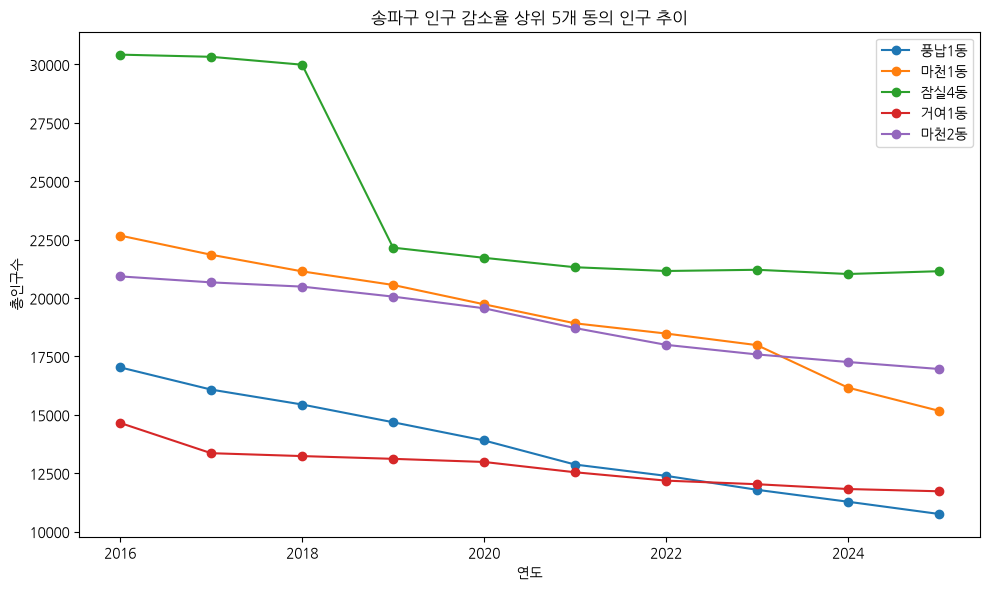

In [83]:
years = list(range(2016, 2026))

plt.figure(figsize=(10, 6))

for dong in decline_top5:

    row = df_dong[df_dong["동"] == dong].iloc[0]

    population = [
        row[f"{year}년_총인구수"]
        for year in years
    ]

    plt.plot(
        years,
        population,
        marker="o",
        label=dong
    )

plt.xlabel("연도")
plt.ylabel("총인구수")
plt.title("송파구 인구 감소율 상위 5개 동의 인구 추이")
plt.legend()

plt.tight_layout()
plt.show()

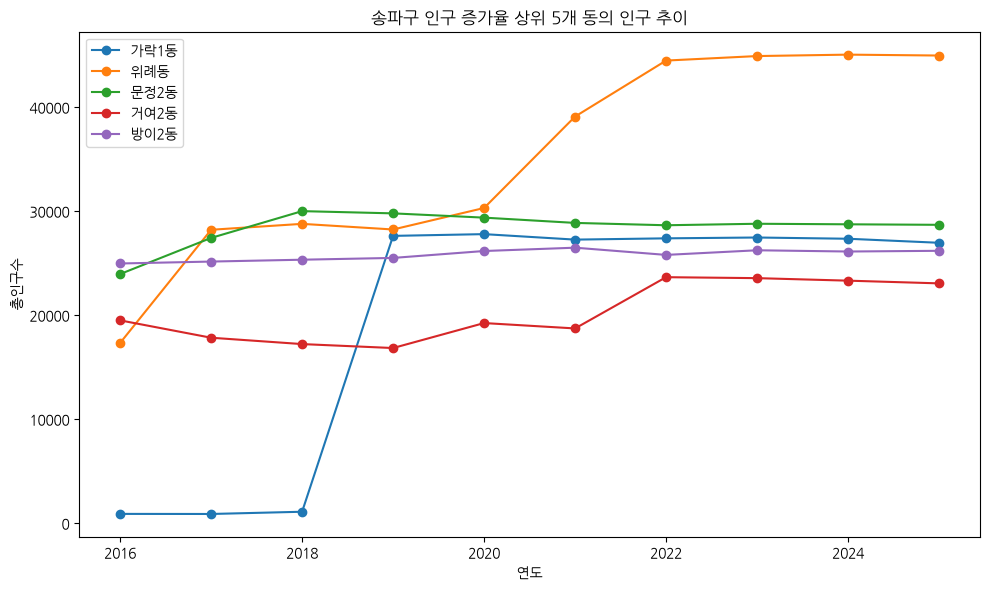

In [112]:
years = list(range(2016, 2026))

plt.figure(figsize=(10, 6))

for dong in incline_top5:

    row = df_dong[df_dong["동"] == dong].iloc[0]

    population = [
        row[f"{year}년_총인구수"]
        for year in years
    ]

    plt.plot(
        years,
        population,
        marker="o",
        label=dong
    )

plt.xlabel("연도")
plt.ylabel("총인구수")
plt.title("송파구 인구 증가율 상위 5개 동의 인구 추이")
plt.legend()

plt.tight_layout()
plt.show()

In [84]:
df_dong["세대수증감률"] = (
    (
        df_dong["2025년_세대수"]
        - df_dong["2016년_세대수"]
    )
    / df_dong["2016년_세대수"]
    * 100
)

In [85]:
population_down_household_up = df_dong[
    (df_dong["인구증감률"] < 0) &
    (df_dong["세대수증감률"] > 0)
]

population_down_household_up[
    [
        "동",
        "인구증감률",
        "세대수증감률",
        "2016년_세대당 인구",
        "2025년_세대당 인구"
    ]
].sort_values("인구증감률")

,동,인구증감률,세대수증감률,2016년_세대당 인구,2025년_세대당 인구
3,거여1동,-19.976795,0.538406,2.63,2.09
14,삼전동,-15.217716,2.540916,2.13,1.76
13,석촌동,-13.106516,4.766292,2.13,1.76
11,송파1동,-12.996994,4.551159,2.20,1.83
15,가락본동,-12.312806,3.610591,2.49,2.11
12,송파2동,-11.229086,2.236682,2.95,2.56
2,풍납2동,-10.621539,0.979252,2.49,2.20
18,문정1동,-8.602050,7.488300,2.58,2.19
7,방이1동,-7.949430,3.451164,2.72,2.42
22,잠실본동,-7.326181,13.139453,2.06,1.69


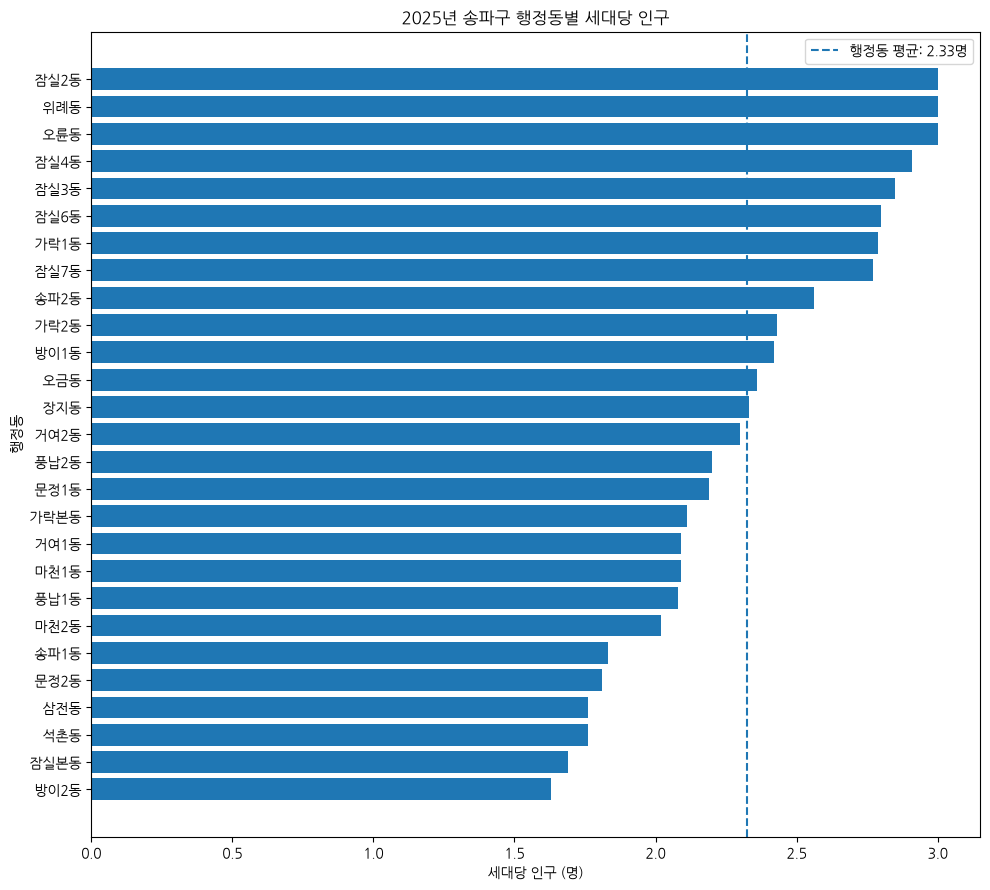

In [86]:
household_2025 = (
    df_dong[["동", "2025년_세대당 인구"]]
    .sort_values("2025년_세대당 인구", ascending=True)
)

plt.figure(figsize=(10, 9))

plt.barh(
    household_2025["동"],
    household_2025["2025년_세대당 인구"]
)

# 송파구 행정동 평균
mean_value = df_dong["2025년_세대당 인구"].mean()

plt.axvline(
    mean_value,
    linestyle="--",
    label=f"행정동 평균: {mean_value:.2f}명"
)

plt.xlabel("세대당 인구 (명)")
plt.ylabel("행정동")
plt.title("2025년 송파구 행정동별 세대당 인구")

plt.legend()
plt.tight_layout()
plt.show()

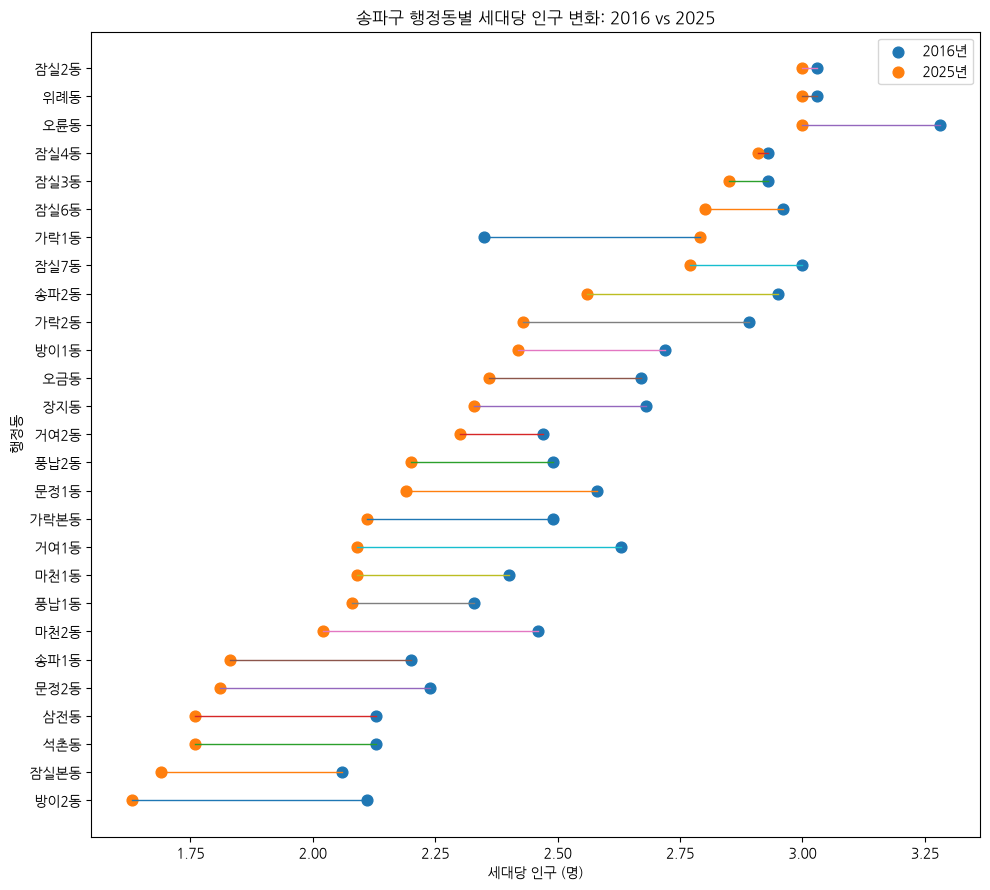

In [87]:
household_compare = df_dong[
    [
        "동",
        "2016년_세대당 인구",
        "2025년_세대당 인구"
    ]
].copy()

household_compare = household_compare.sort_values(
    "2025년_세대당 인구"
)

plt.figure(figsize=(10, 9))

# 2016년과 2025년 점을 연결
for _, row in household_compare.iterrows():

    plt.plot(
        [
            row["2016년_세대당 인구"],
            row["2025년_세대당 인구"]
        ],
        [
            row["동"],
            row["동"]
        ],
        linewidth=1
    )

# 2016
plt.scatter(
    household_compare["2016년_세대당 인구"],
    household_compare["동"],
    s=60,
    label="2016년"
)

# 2025
plt.scatter(
    household_compare["2025년_세대당 인구"],
    household_compare["동"],
    s=60,
    label="2025년"
)

plt.xlabel("세대당 인구 (명)")
plt.ylabel("행정동")
plt.title("송파구 행정동별 세대당 인구 변화: 2016 vs 2025")

plt.legend()
plt.tight_layout()
plt.show()

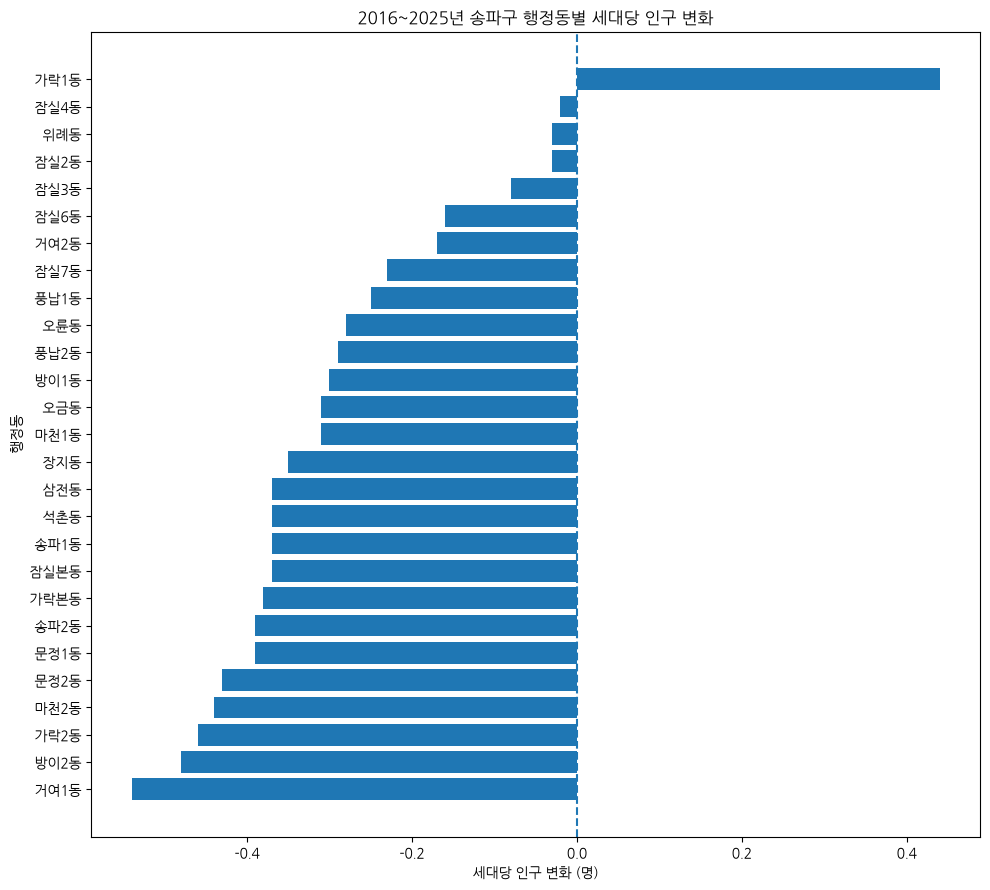

In [88]:
df_dong["세대당인구_변화"] = (
    df_dong["2025년_세대당 인구"]
    - df_dong["2016년_세대당 인구"]
)

household_size_change = (
    df_dong[["동", "세대당인구_변화"]]
    .sort_values("세대당인구_변화")
)

plt.figure(figsize=(10, 9))

plt.barh(
    household_size_change["동"],
    household_size_change["세대당인구_변화"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("세대당 인구 변화 (명)")
plt.ylabel("행정동")
plt.title("2016~2025년 송파구 행정동별 세대당 인구 변화")

plt.tight_layout()
plt.show()

In [89]:
# 면적 데이터 불러오기
df_area = pd.read_csv(
    "./pop_datas/행정구역(동별)_20260820104833.csv",
    encoding="utf-8"
)

# 송파구 행정동만 추출
area_songpa = df_area[
    (df_area["동별(2)"] == "송파구") &
    (df_area["동별(3)"] != "소계")
][["동별(3)", "2025"]].copy()

# 컬럼명 정리
area_songpa.columns = ["동", "면적"]

# 면적을 숫자형으로 변환
area_songpa["면적"] = pd.to_numeric(
    area_songpa["면적"],
    errors="coerce"
)

area_songpa.head()

,동,면적
4,풍납1동,0.77
5,풍납2동,1.59
6,거여1동,0.51
7,거여2동,0.53
8,마천1동,0.58


In [90]:
df_dong = df_dong.merge(
    area_songpa,
    on="동",
    how="left"
)

In [91]:
df_dong[["동", "면적"]]

,동,면적
0,풍납1동,0.77
1,풍납2동,1.59
2,거여1동,0.51
3,거여2동,0.53
4,마천1동,0.58
5,마천2동,0.89
6,방이1동,0.50
7,방이2동,0.80
8,오륜동,3.17
9,오금동,1.65


In [92]:
df_dong["2025년_인구밀도"] = (
    df_dong["2025년_총인구수"]
    / df_dong["면적"]
)

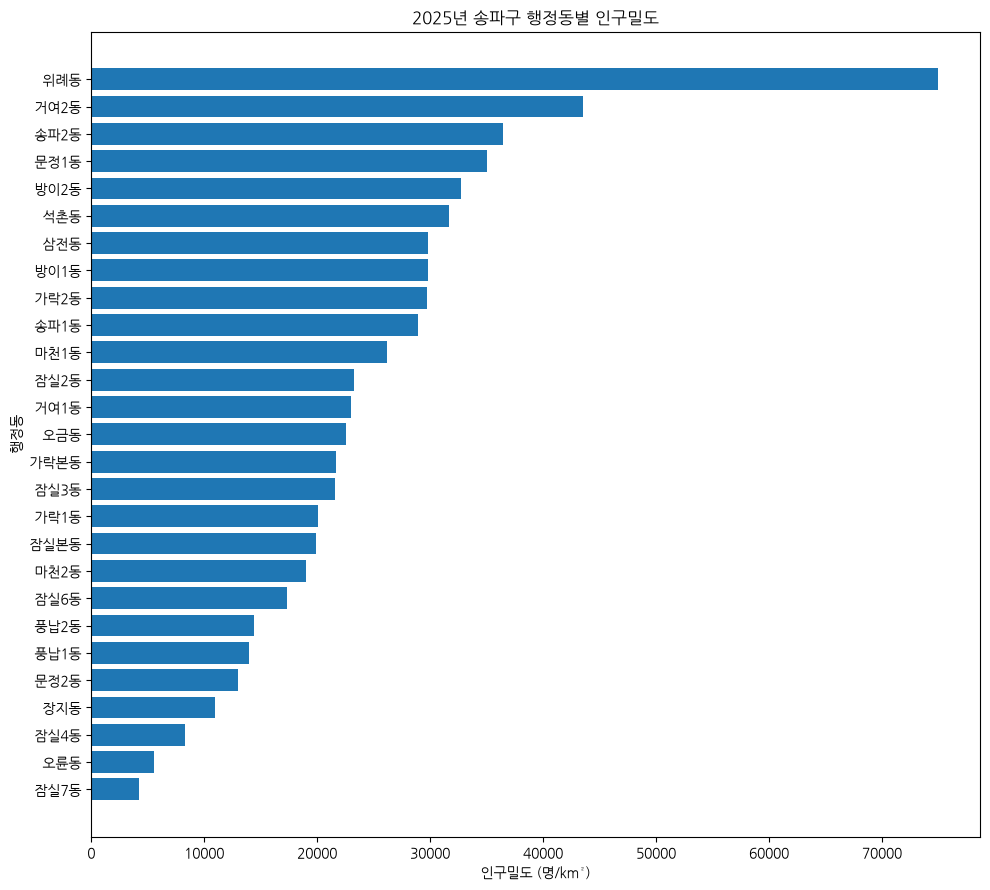

In [93]:
density = (
    df_dong[["동", "2025년_인구밀도"]]
    .sort_values("2025년_인구밀도", ascending=True)
)

plt.figure(figsize=(10, 9))

plt.barh(
    density["동"],
    density["2025년_인구밀도"]
)

plt.xlabel("인구밀도 (명/km²)")
plt.ylabel("행정동")
plt.title("2025년 송파구 행정동별 인구밀도")

plt.tight_layout()
plt.show()

In [95]:
import pandas as pd

df_age1 = pd.read_csv(
    "./pop_datas/201612_202012_연령별인구현황_연간.csv",
    encoding="cp949"
)

df_age2 = pd.read_csv(
    "./pop_datas/202112_202512_연령별인구현황_연간.csv",
    encoding="cp949"
)

# 행정구역을 기준으로 2016~2025 데이터 결합
df_age = df_age1.merge(
    df_age2,
    on="행정구역",
    how="inner"
)

df_age.shape

(28, 391)

In [96]:
# 송파구 전체
age_songpa = df_age.iloc[[0]].copy()

# 27개 행정동
age_dong = df_age.iloc[1:].copy()

# 동 이름 추출
age_dong["동"] = (
    age_dong["행정구역"]
    .str.replace("서울특별시 송파구 ", "", regex=False)
    .str.replace(r"\(\d+\)", "", regex=True)
    .str.strip()
)

In [97]:
for col in df_age.columns:
    if col != "행정구역":
        df_age[col] = pd.to_numeric(
            df_age[col].astype(str).str.replace(",", "", regex=False),
            errors="coerce"
        )

In [98]:
import pandas as pd

df_age1 = pd.read_csv(
    "./pop_datas/201612_202012_연령별인구현황_연간.csv",
    encoding="cp949"
)

df_age2 = pd.read_csv(
    "./pop_datas/202112_202512_연령별인구현황_연간.csv",
    encoding="cp949"
)

# 결합
df_age = df_age1.merge(
    df_age2,
    on="행정구역",
    how="inner"
)

# 숫자형 변환
for col in df_age.columns:
    if col != "행정구역":
        df_age[col] = pd.to_numeric(
            df_age[col]
            .astype(str)
            .str.replace(",", "", regex=False),
            errors="coerce"
        )

# 송파구 전체
age_songpa = df_age.iloc[[0]].copy()

# 행정동
age_dong = df_age.iloc[1:].copy()

age_dong["동"] = (
    age_dong["행정구역"]
    .str.replace("서울특별시 송파구 ", "", regex=False)
    .str.replace(r"\(\d+\)", "", regex=True)
    .str.strip()
)

print(age_dong[["동", "2016년_계_총인구수", "2025년_계_총인구수"]].head())

      동  2016년_계_총인구수  2025년_계_총인구수
1  풍납1동         17031         10753
2  풍납2동         25646         22922
3  거여1동         14652         11725
4  거여2동         19502         23058
5  마천1동         22674         15169


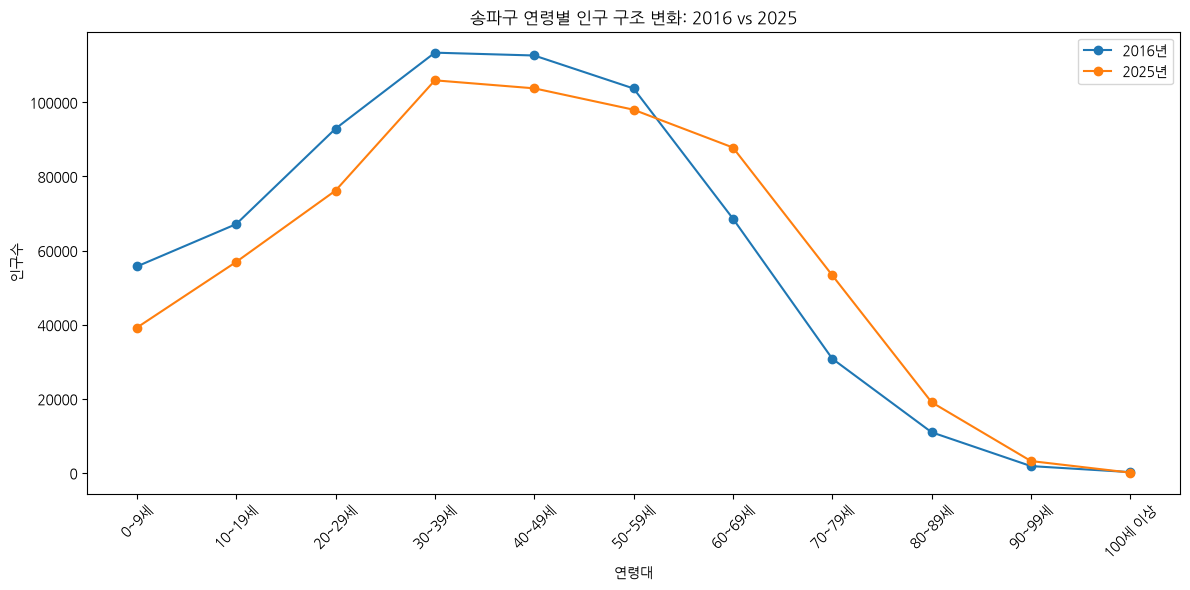

In [99]:
import matplotlib.pyplot as plt

age_groups = [
    "0~9세",
    "10~19세",
    "20~29세",
    "30~39세",
    "40~49세",
    "50~59세",
    "60~69세",
    "70~79세",
    "80~89세",
    "90~99세",
    "100세 이상"
]

row = age_songpa.iloc[0]

pop_2016 = [
    row[f"2016년_계_{age}"]
    for age in age_groups
]

pop_2025 = [
    row[f"2025년_계_{age}"]
    for age in age_groups
]

x = range(len(age_groups))

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    pop_2016,
    marker="o",
    label="2016년"
)

plt.plot(
    x,
    pop_2025,
    marker="o",
    label="2025년"
)

plt.xticks(x, age_groups, rotation=45)
plt.ylabel("인구수")
plt.xlabel("연령대")
plt.title("송파구 연령별 인구 구조 변화: 2016 vs 2025")
plt.legend()

plt.tight_layout()
plt.show()

In [101]:
age_dong["2025년_0_19세"] = (
    age_dong["2025년_계_0~9세"]
    + age_dong["2025년_계_10~19세"]
)

age_dong["2025년_0_19세비율"] = (
    age_dong["2025년_0_19세"]
    / age_dong["2025년_계_총인구수"]
    * 100
)

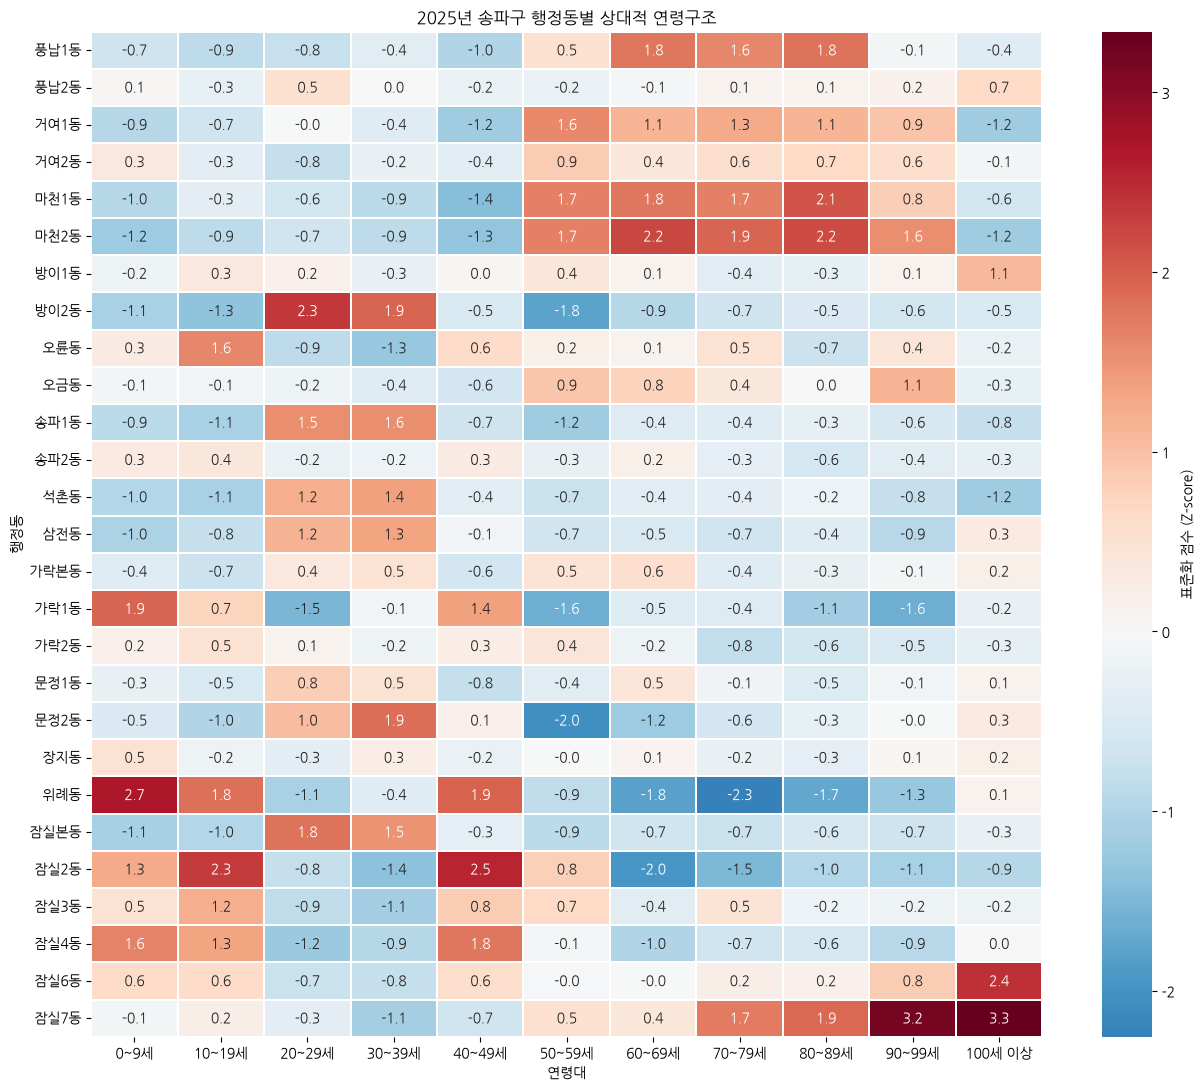

In [102]:
# 연령대별로 동 간 표준화
heatmap_z = (
    heatmap_data - heatmap_data.mean()
) / heatmap_data.std()

plt.figure(figsize=(13, 11))

sns.heatmap(
    heatmap_z,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar_kws={"label": "표준화 점수 (Z-score)"}
)

plt.xlabel("연령대")
plt.ylabel("행정동")
plt.title("2025년 송파구 행정동별 상대적 연령구조")

plt.tight_layout()
plt.show()

Z-score Heatmap
- 0 근처: 송파구 행정동 평균적인 구성
- 양수: 해당 연령대 비율이 다른 동보다 높은 편
- 음수: 해당 연령대 비율이 다른 동보다 낮은 편
- +2 정도: 매우 높은 편
- -2 정도: 매우 낮은 편

In [103]:
analysis = pd.DataFrame({
    "동": age_dong["동"],
    
    "0~9세비율":
        age_dong["2025년_계_0~9세"].values
        / age_dong["2025년_계_총인구수"].values * 100,
    
    "30~39세비율":
        age_dong["2025년_계_30~39세"].values
        / age_dong["2025년_계_총인구수"].values * 100
})

In [104]:
analysis = analysis.merge(
    df_dong[
        ["동", "2025년_세대당 인구"]
    ],
    on="동"
)

analysis.head()

,동,0~9세비율,30~39세비율,2025년_세대당 인구
0,풍납1동,4.036083,14.070492,2.08
1,풍납2동,5.854637,16.119885,2.20
2,거여1동,3.411514,13.842217,2.09
3,거여2동,6.587735,14.810478,2.30
4,마천1동,3.375305,11.200475,2.09


In [105]:
median_household = analysis["2025년_세대당 인구"].median()

high_household = analysis[
    analysis["2025년_세대당 인구"] >= median_household
]

low_household = analysis[
    analysis["2025년_세대당 인구"] < median_household
]

In [106]:
import pandas as pd

age_groups = [
    "0~9세",
    "10~19세",
    "20~29세",
    "30~39세",
    "40~49세",
    "50~59세",
    "60~69세",
    "70~79세",
    "80~89세",
    "90~99세",
    "100세 이상"
]

# 1. 2025년 연령대별 비율 생성
age_ratio = pd.DataFrame({
    "동": age_dong["동"].values
})

for age in age_groups:
    age_ratio[age] = (
        age_dong[f"2025년_계_{age}"].values
        / age_dong["2025년_계_총인구수"].values
        * 100
    )

# 2. 세대당 인구 결합
analysis_age = age_ratio.merge(
    df_dong[["동", "2025년_세대당 인구"]],
    on="동",
    how="inner"
)

# 3. 동을 index로 설정
analysis_age = analysis_age.set_index("동")

# 4. 세대당 인구 중앙값 기준으로 그룹 분리
median_household = analysis_age["2025년_세대당 인구"].median()

high = analysis_age[
    analysis_age["2025년_세대당 인구"] >= median_household
].copy()

low = analysis_age[
    analysis_age["2025년_세대당 인구"] < median_household
].copy()

# 5. 각 그룹의 연령대 간 correlation
corr_high = high[age_groups].corr(method="pearson")
corr_low = low[age_groups].corr(method="pearson")

print(f"세대당 인구 중앙값: {median_household:.2f}명")
print(f"High 그룹: {len(high)}개 동")
print(f"Low 그룹: {len(low)}개 동")

세대당 인구 중앙값: 2.30명
High 그룹: 14개 동
Low 그룹: 13개 동


In [107]:
corr_diff = corr_high - corr_low

corr_diff

,0~9세,10~19세,20~29세,30~39세,40~49세,50~59세,60~69세,70~79세,80~89세,90~99세,100세 이상
0~9세,0.000000,0.057521,-0.672166,0.061886,0.508286,-0.561122,-0.708262,-0.547387,-0.421089,-0.680308,-0.998953
10~19세,0.057521,0.000000,0.071726,0.039347,1.176551,-0.771738,-1.310950,-0.974831,-0.939116,-0.980301,-0.664450
20~29세,-0.672166,0.071726,0.000000,-0.628524,-1.329367,1.398153,1.429078,1.105425,1.225098,1.216096,0.009742
30~39세,0.061886,0.039347,-0.628524,0.000000,-1.166525,0.588434,1.250638,0.713480,0.696318,0.609256,-0.402873
40~49세,0.508286,1.176551,-1.329367,-1.166525,0.000000,0.433745,-0.054879,0.102133,0.078443,-0.056946,-1.038030
50~59세,-0.561122,-0.771738,1.398153,0.588434,0.433745,0.000000,-0.625374,-0.464338,-0.293997,-0.263203,0.428874
60~69세,-0.708262,-1.310950,1.429078,1.250638,-0.054879,-0.625374,0.000000,-0.135447,-0.255384,-0.104824,0.731959
70~79세,-0.547387,-0.974831,1.105425,0.713480,0.102133,-0.464338,-0.135447,0.000000,-0.112771,-0.000894,0.997166
80~89세,-0.421089,-0.939116,1.225098,0.696318,0.078443,-0.293997,-0.255384,-0.112771,0.000000,0.105682,1.166436
90~99세,-0.680308,-0.980301,1.216096,0.609256,-0.056946,-0.263203,-0.104824,-0.000894,0.105682,0.000000,1.067447


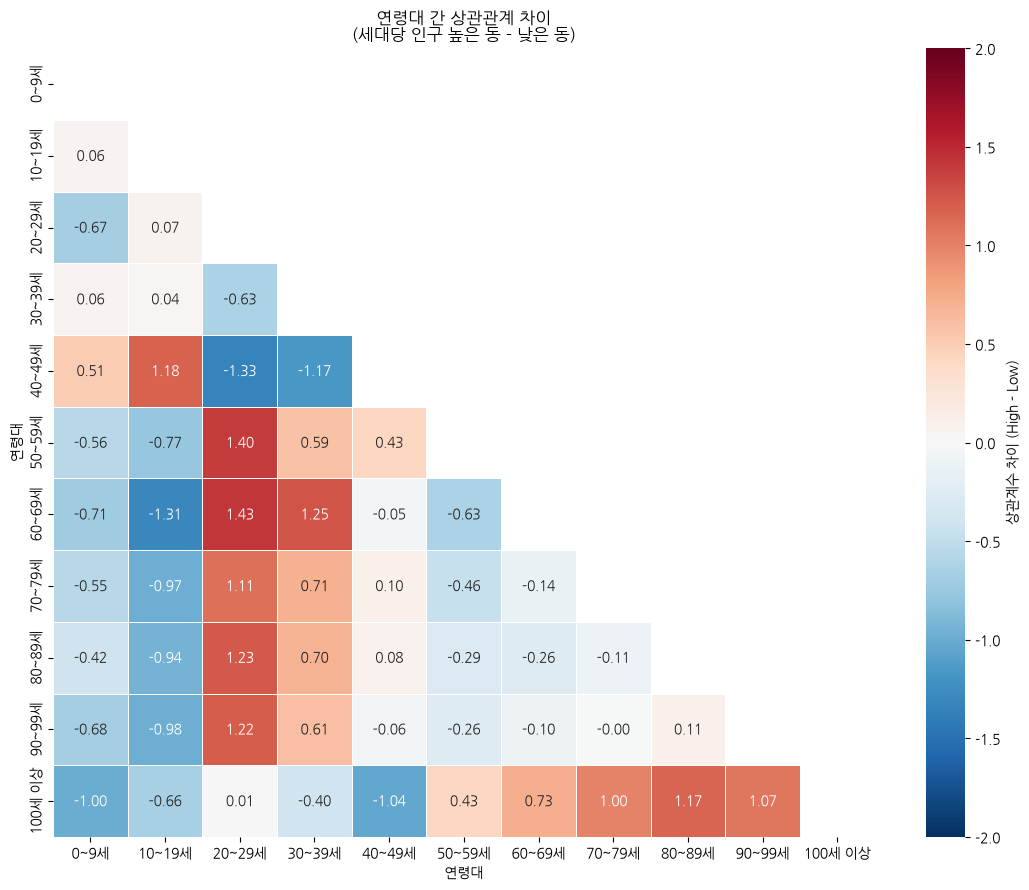

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 대각선 + 상삼각형 가리기
mask = np.triu(
    np.ones_like(corr_diff, dtype=bool)
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    corr_diff,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-2,
    vmax=2,
    linewidths=0.5,
    cbar_kws={
        "label": "상관계수 차이 (High - Low)"
    }
)

plt.title(
    "연령대 간 상관관계 차이\n"
    "(세대당 인구 높은 동 - 낮은 동)"
)

plt.xlabel("연령대")
plt.ylabel("연령대")

plt.tight_layout()
plt.show()

In [109]:
results = []

for i, age1 in enumerate(age_groups):
    for age2 in age_groups[i + 1:]:

        r_high = corr_high.loc[age1, age2]
        r_low = corr_low.loc[age1, age2]

        results.append({
            "연령대1": age1,
            "연령대2": age2,
            "High_r": r_high,
            "Low_r": r_low,
            "차이": r_high - r_low
        })

corr_compare = pd.DataFrame(results)

candidate = corr_compare[
    (corr_compare["High_r"] >= 0.5) &
    (corr_compare["차이"] >= 0.3)
]

candidate

,연령대1,연령대2,High_r,Low_r,차이
3,0~9세,40~49세,0.819577,0.311291,0.508286
12,10~19세,40~49세,0.897588,-0.278963,1.176551
21,20~29세,50~59세,0.530588,-0.867565,1.398153
22,20~29세,60~69세,0.510241,-0.918838,1.429078
51,70~79세,100세 이상,0.530632,-0.466534,0.997166
53,80~89세,100세 이상,0.702399,-0.464037,1.166436
54,90~99세,100세 이상,0.735919,-0.331528,1.067447
